# Benchmark plotting

## `float32` 

In [39]:
import json
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

In [14]:
def load(paths: list[Path]) -> tuple[dict, dict]:
    """Merge sweep files -> {(writer, dtype, size): row}, plus metadata."""
    groups: dict[tuple, list[dict]] = defaultdict(list)
    meta = {}
    for p in paths:
        blob = json.loads(p.read_text())
        meta = meta or blob["meta"]          # first file's machine info
        for row in blob["rows"]:
            groups[(row["writer"], row["dtype"], row["size"])].append(row)
 
    merged = {}
    for key, rows in groups.items():
        # median across repeats of the per-repeat medians
        med = float(np.median([r["ms_median"] for r in rows]))
        merged[key] = {
            **rows[0],
            "ms_median": med,
            "ms_p10": float(np.median([r["ms_p10"] for r in rows])),
            "ms_p90": float(np.median([r["ms_p90"] for r in rows])),
            "gbps": rows[0]["payload_bytes"] / (med * 1e-3) / 1e9,
            "n_repeats": len(rows),
        }
    return merged, meta

In [15]:
parent_path = Path("./results/")

In [28]:
data, meta = load([parent_path.joinpath("sweep_bf32.json"), 
                   parent_path.joinpath("sweep_bf32_4096_shared.json"), 
                   parent_path.joinpath("sweep_bf32_4096_host.json"), 
                   parent_path.joinpath("sweep_bf32_2048_shared.json"), 
                  parent_path.joinpath("sweep_bf32_2048_host.json"),
                  parent_path.joinpath("sweep_bf32_naive.json"),
                  parent_path.joinpath("sweep_bf32_2048_naive.json"),
                  parent_path.joinpath("sweep_bf32_4096_naive.json"),
                  parent_path.joinpath("sweep_bf16.json"), 
                   parent_path.joinpath("sweep_bf16_4096_shared.json"), 
                   parent_path.joinpath("sweep_bf16_4096_host.json"), 
                   parent_path.joinpath("sweep_bf16_2048_shared.json"), 
                  parent_path.joinpath("sweep_bf16_2048_host.json"),
                  parent_path.joinpath("sweep_bf16_naive.json"),
                  parent_path.joinpath("sweep_bf16_2048_naive.json"),
                  parent_path.joinpath("sweep_bf16_4096_naive.json")])

In [29]:
data.keys()

dict_keys([('shared', 'float32', 64), ('host', 'float32', 64), ('shared', 'float32', 256), ('host', 'float32', 256), ('shared', 'float32', 512), ('host', 'float32', 512), ('shared', 'float32', 1024), ('host', 'float32', 1024), ('shared', 'float32', 4096), ('host', 'float32', 4096), ('shared', 'float32', 2048), ('host', 'float32', 2048), ('host_naive', 'float32', 64), ('host_naive', 'float32', 256), ('host_naive', 'float32', 512), ('host_naive', 'float32', 1024), ('host_naive', 'float32', 2048), ('host_naive', 'float32', 4096), ('host', 'bfloat16', 64), ('shared', 'bfloat16', 64), ('host', 'bfloat16', 256), ('shared', 'bfloat16', 256), ('host', 'bfloat16', 512), ('shared', 'bfloat16', 512), ('host', 'bfloat16', 1024), ('shared', 'bfloat16', 1024), ('shared', 'bfloat16', 4096), ('host', 'bfloat16', 4096), ('shared', 'bfloat16', 2048), ('host', 'bfloat16', 2048), ('host_naive', 'bfloat16', 64), ('host_naive', 'bfloat16', 256), ('host_naive', 'bfloat16', 512), ('host_naive', 'bfloat16', 10

In [145]:
def print_table(data):
    """Markdown table for pasting straight into the post."""
    sizes = sorted({k[2] for k in data})
    for dtype in ("float32", "bfloat16"):
        rows = [(s, data.get(("shared", dtype, s), {}).get("ms_median"),
                 data.get(("host", dtype, s), {}).get("ms_median"))
                for s in sizes]
        rows = [r for r in rows if r[1] and r[2]]
        if not rows:
            continue
        print(f"\n### {dtype}\n")
        print("| size | shared (ms) | host (ms) | speedup |")
        print("|---|---|---|---|")
        for s, sh, ho in rows:
            print(f"| {s}² | {sh:.3f} | {ho:.3f} | {ho/sh:.1f}× |")

In [147]:
def print_table(data):
    """Markdown tables for pasting straight into the post."""
    sizes = sorted({k[2] for k in data})

    for dtype in ("float32", "bfloat16"):
        itemsize = 2 if dtype == "bfloat16" else 4
        rows = []
        for s in sizes:
            sh = data.get(("shared", dtype, s), {}).get("ms_median")
            ho = data.get(("host", dtype, s), {}).get("ms_median")
            na = data.get(("host_naive", dtype, s), {}).get("ms_median")
            if sh is None and ho is None and na is None:
                continue
            rows.append((s, s * s * itemsize, sh, ho, na))
        if not rows:
            continue

        def cell(v):
            return "—" if v is None else f"{v:.3f}"

        def ratio(num, den):
            return "—" if (num is None or not den) else f"{num/den:.1f}×"

        print(f"\n### {dtype}\n")
        print("| size | payload | shared (ms) | host pinned (ms) | "
              "host naive (ms) | vs pinned | vs naive |")
        print("|---|---|---|---|---|---|---|")
        for s, nbytes, sh, ho, na in rows:
            print(f"| {s}² | {_fmt_bytes(nbytes)} | {cell(sh)} | {cell(ho)} | "
                  f"{cell(na)} | {ratio(ho, sh)} | {ratio(na, sh)} |")

In [148]:
print_table(data)


### float32

| size | payload | shared (ms) | host pinned (ms) | host naive (ms) | vs pinned | vs naive |
|---|---|---|---|---|---|---|
| 64² | 16 KB | 0.202 | 0.087 | 0.090 | 0.4× | 0.4× |
| 256² | 256 KB | 0.209 | 0.143 | 0.173 | 0.7× | 0.8× |
| 512² | 1.0 MB | 0.229 | 0.336 | 0.415 | 1.5× | 1.8× |
| 1024² | 4.0 MB | 0.302 | 1.119 | 1.197 | 3.7× | 4.0× |
| 2048² | 16 MB | 0.632 | 3.873 | 4.067 | 6.1× | 6.4× |
| 4096² | 64 MB | 1.178 | 14.604 | 32.116 | 12.4× | 27.3× |

### bfloat16

| size | payload | shared (ms) | host pinned (ms) | host naive (ms) | vs pinned | vs naive |
|---|---|---|---|---|---|---|
| 64² | 8.0 KB | 0.205 | 0.263 | 0.256 | 1.3× | 1.2× |
| 256² | 128 KB | 0.214 | 0.321 | 0.344 | 1.5× | 1.6× |
| 512² | 512 KB | 0.234 | 0.510 | 0.582 | 2.2× | 2.5× |
| 1024² | 2.0 MB | 0.304 | 1.440 | 1.501 | 4.7× | 4.9× |
| 2048² | 8.0 MB | 0.627 | 4.247 | 4.370 | 6.8× | 7.0× |
| 4096² | 32 MB | 1.272 | 15.237 | 32.906 | 12.0× | 25.9× |


In [44]:
# Colors chosen to match the blog diagrams: coral = host/CUDA-side path,
# teal = the shared path.
STYLE = {
    "shared":     {"color": "#3f9e94", "marker": "o", "label": "shared memory"},
    "host":       {"color": "#e07a5f", "marker": "s", "label": "host round trip (pinned)"},
    "host_naive": {"color": "#c9a227", "marker": "^", "label": "host round trip (naive .cpu())"},
}
DTYPE_LS = {"float32": "-", "bfloat16": "--"}
 
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})

In [48]:
def series(data: dict, writer: str, dtype: str, field: str):
    """Sorted (sizes, values) for one writer/dtype line."""
    pts = sorted((k[2], v) for k, v in data.items()
                 if k[0] == writer and k[1] == dtype)
    if not pts:
        return np.array([]), np.array([])
    return (np.array([s for s, _ in pts]),
            np.array([v[field] for _, v in pts]))

def machine_note(meta: dict) -> str:
    gpu = meta.get("gpu", "?")
    drv = "driver " + str(meta.get("adapter", "")).split("description='")[-1].split("'")[0]
    return f"{gpu} · torch {meta.get('torch','?')} · {drv}"

In [135]:
def save(fig, out: Path, name: str):
    out.mkdir(parents=True, exist_ok=True)
    for ext in ("png", "svg"):
        path = out / f"{name}.{ext}"
        fig.savefig(path)
        print(f"wrote {path}")
    plt.close(fig)

In [141]:
def _fmt_bytes(n: int) -> str:
    for unit, div in (("GB", 1 << 30), ("MB", 1 << 20), ("KB", 1 << 10)):
        if n >= div:
            v = n / div
            return f"{v:.0f} {unit}" if v >= 10 else f"{v:.1f} {unit}"
    return f"{n} B"


def fig_latency(data, meta, out: Path, dtype: str = "float32"):
    """Grouped bars: one cluster per tensor size, one bar per writer."""
    sizes = sorted({k[2] for k in data if k[1] == dtype})
    writers = [w for w in ("shared", "host", "host_naive")
               if any((w, dtype, s) in data for s in sizes)]
    if not sizes or not writers:
        print(f"[skip] no {dtype} rows for the latency figure")
        return

    fig, ax = plt.subplots(figsize=(7.8, 5.0))

    x = np.arange(len(sizes))
    bw = 0.8 / len(writers)

    # ---- bars -------------------------------------------------------------
    tops = {}                      # (writer, size) -> bar top, for labels
    for i, writer in enumerate(writers):
        vals = [data.get((writer, dtype, s), {}).get("ms_median", np.nan)
                for s in sizes]
        offset = (i - (len(writers) - 1) / 2) * bw
        st = STYLE[writer]
        bars = ax.bar(x + offset, vals, bw * 0.92,
                      color=st["color"], label=st["label"],
                      edgecolor="white", linewidth=0.6, zorder=3)
        for b, v, s in zip(bars, vals, sizes):
            if np.isnan(v):
                continue
            tops[(writer, s)] = v
            ax.text(b.get_x() + b.get_width() / 2, v * 1.10,
                    f"{v:.2g}", ha="center", va="bottom",
                    fontsize=7, color="#333", zorder=4)

    ax.set_yscale("log")

    # # ---- 60 fps budget: shaded region above 16.7 ms -----------------------
    # ax.axhspan(16.7, 1e4, color="#c94f4f", alpha=0.07, zorder=0)
    # ax.axhline(16.7, color="#c94f4f", lw=1, ls="--", alpha=0.6, zorder=1)
    # ax.text(len(sizes) - 0.5, 17.6, "misses 60 fps", ha="right", va="bottom",
    #         fontsize=8, color="#c94f4f", zorder=4)

    # ---- axes -------------------------------------------------------------
    payloads = {s: s * s * (2 if dtype == "bfloat16" else 4) for s in sizes}
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s}²\n{_fmt_bytes(payloads[s])}" for s in sizes])
    ax.set_xlabel("tensor size", labelpad=8)
    ax.set_ylabel("update time (ms)")
    ax.set_xlim(-0.6, len(sizes) - 0.4)
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", which="minor", alpha=0.12)

    # headroom for the regime brackets, then clamp so the 60fps band shows
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, max(ymax, 20) * 3.0)

    # ---- regime annotations ----------------------------------------------
    big = [j for j, s in enumerate(sizes) if payloads[s] >= 1 << 20]
    small = [j for j in range(len(sizes)) if j not in big]

    def bracket(idxs, label, color):
        if not idxs:
            return
        x0, x1 = min(idxs) - 0.44, max(idxs) + 0.44
        y = ax.get_ylim()[1] * 0.42
        ax.annotate("", xy=(x0, y), xytext=(x1, y),
                    arrowprops=dict(arrowstyle="-", color=color,
                                    lw=1.1, alpha=0.7), zorder=2)
        ax.text((x0 + x1) / 2, y * 1.15, label, ha="center", va="bottom",
                fontsize=8.5, color=color, style="italic", zorder=4)

    bracket(small, "fixed overhead dominates", "#777")
    bracket(big, "PCIe-bound", "#c94f4f")

    # ---- title, subtitle, legend -----------------------------------------
    ax.set_title(
        f"Getting a CUDA tensor onto a wgpu texture ({dtype})",
        fontweight="bold", fontsize=12, pad=26,
    )
    ax.text(0.5, 1.012, machine_note(meta), transform=ax.transAxes,
            fontsize=8, color="#666", ha="center", va="bottom")

    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17),
              ncol=len(writers), fontsize=8.5)

    save(fig, out, f"fig_latency_{dtype}")

In [138]:
fig_latency(data, meta, Path("./results/"))

wrote results/fig_latency.png
wrote results/fig_latency.svg


In [142]:
fig_latency(data, meta, Path("./results/"), "bfloat16")

wrote results/fig_latency_bfloat16.png
wrote results/fig_latency_bfloat16.svg


In [61]:
def fig_bandwidth(data, meta):
    fig, ax = plt.subplots(figsize=(7, 4.6))
 
    for dtype in ("float32", "bfloat16"):
        for writer in ("shared", "host", "host_naive"):
            sizes, gbps = series(data, writer, dtype, "gbps")
            if not len(sizes):
                continue
            st = STYLE[writer]
            ax.plot(sizes, gbps, ls=DTYPE_LS[dtype], color=st["color"],
                    marker=st["marker"], ms=4.5, lw=1.8,
                    label=f"{st['label']} · {dtype}")
 
    ax.set_xscale("log", base=2)
    ax.set_xticks([64, 128, 256, 512, 1024, 2048, 4096])
    ax.set_xticklabels([f"{s}²" for s in [64, 128, 256, 512, 1024, 2048, 4096]])
    ax.set_xlabel("tensor size (elements per side)")
    ax.set_ylabel("effective payload bandwidth (GB/s)")
    ax.set_title("The host path has a ceiling; the shared path has a floor",
                 loc="left", fontweight="bold")
    ax.text(0, 1.02, machine_note(meta), transform=ax.transAxes,
            fontsize=8, color="#666", va="bottom")
    ax.legend(loc="upper left", fontsize=8.5)


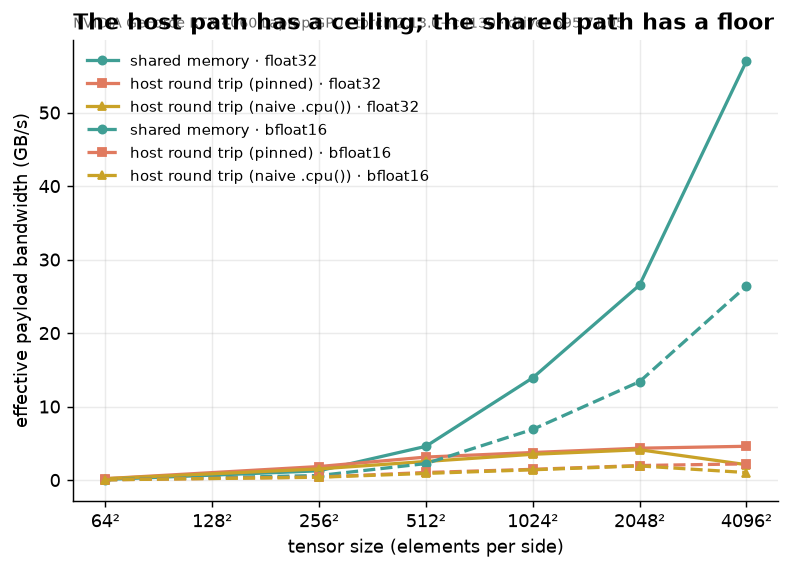

In [62]:
fig_bandwidth(data, meta)